# Prédiction du prix des appartements à Paris

**Objectif :** estimer le prix de vente d'un appartement parisien à partir de sa surface, de son nombre de pièces et de son arrondissement.

**Données :** transactions immobilières réelles à Paris (2018-2019), issues des Demandes de Valeurs Foncières (DVF).

**Démarche :**
1. Chargement et préparation des données
2. Analyse exploratoire : quels facteurs font le prix ?
3. Modélisation par régression linéaire
4. Évaluation et interprétation des résultats
5. Limites et pistes d'amélioration

## 1. Chargement et préparation des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")

In [2]:
url = "https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/transactions_immobilieres_75.csv"
df_transactions = pd.read_csv(url)

print(f"{len(df_transactions):,} transactions chargées".replace(",", " "))
df_transactions.head()

53 185 transactions chargées


,id_mutation,valeur_fonciere,surface_reelle_bati,prix_m2,nombre_pieces_principales,type_local,nom_commune,nom_iris,code_commune,code_departement,code_iris,id_parcelles,longitude,latitude,date_mutation
0,2018-1404085,280000.0,25,11200,2,appartement,Paris 20e Arrondissement,Belleville 4,75120,75,751207704,75120000AL0064,2.389542,48.872300,2018-01-02
1,2018-1384130,110000.0,12,9166,1,appartement,Paris 14e Arrondissement,Montparnasse 4,75114,75,751145304,75114000AM0068,2.326280,48.835690,2018-01-02
2,2018-1376276,87950.0,9,9772,1,appartement,Paris 11e Arrondissement,Roquette 2,75111,75,751114302,75111000BS0234,2.386354,48.856080,2018-01-02
3,2018-1382007,699000.0,111,6297,6,appartement,Paris 13e Arrondissement,Maison Blanche 18,75113,75,751135118,75113000EI0007,2.343125,48.829746,2018-01-02
4,2018-1376139,251000.0,29,8655,2,appartement,Paris 12e Arrondissement,Picpus 5,75112,75,751124605,75112000BS0026,2.396901,48.834740,2018-01-02


On ne garde que les appartements, puis on vérifie les valeurs manquantes.

In [3]:
df_flats = df_transactions[df_transactions["type_local"] == "appartement"].copy()

print(f"Nombre d'appartements : {len(df_flats):,}".replace(",", " "))
print("\nValeurs manquantes par colonne :")
print(df_flats[["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "code_commune"]].isna().sum())

Nombre d'appartements : 48 921

Valeurs manquantes par colonne :
valeur_fonciere              0
surface_reelle_bati          0
nombre_pieces_principales    0
code_commune                 0
dtype: int64


In [4]:
# Création d'une colonne lisible pour l'arrondissement (75101 -> 1)
df_flats["arrondissement"] = df_flats["code_commune"] - 75100

df_flats[["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales"]].describe().round(0)

,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales
count,48921.0,48921.0,48921.0
mean,487141.0,47.0,2.0
std,432874.0,34.0,1.0
min,13225.0,3.0,0.0
25%,240000.0,26.0,1.0
50%,370000.0,39.0,2.0
75%,585000.0,59.0,3.0
max,17865830.0,1500.0,23.0


## 2. Analyse exploratoire

### Prix au m² par arrondissement

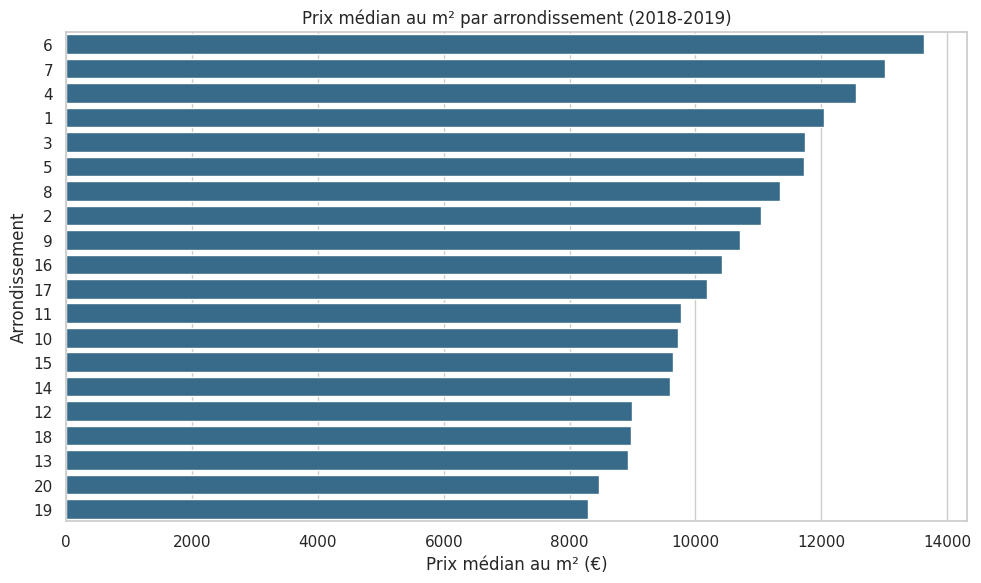

In [5]:
prix_m2_arr = (
    df_flats.groupby("arrondissement")["prix_m2"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=prix_m2_arr.values, y=prix_m2_arr.index.astype(str), color="#2a6f97")
plt.title("Prix médian au m² par arrondissement (2018-2019)")
plt.xlabel("Prix médian au m² (€)")
plt.ylabel("Arrondissement")
plt.tight_layout()
plt.show()

**Lecture :** le prix au m² varie fortement selon l'arrondissement. Les arrondissements centraux et de l'ouest (6e, 7e, 4e…) sont nettement plus chers que ceux de l'est et du nord (19e, 20e…). L'arrondissement est donc une variable indispensable pour le modèle.

### Relation entre surface et prix

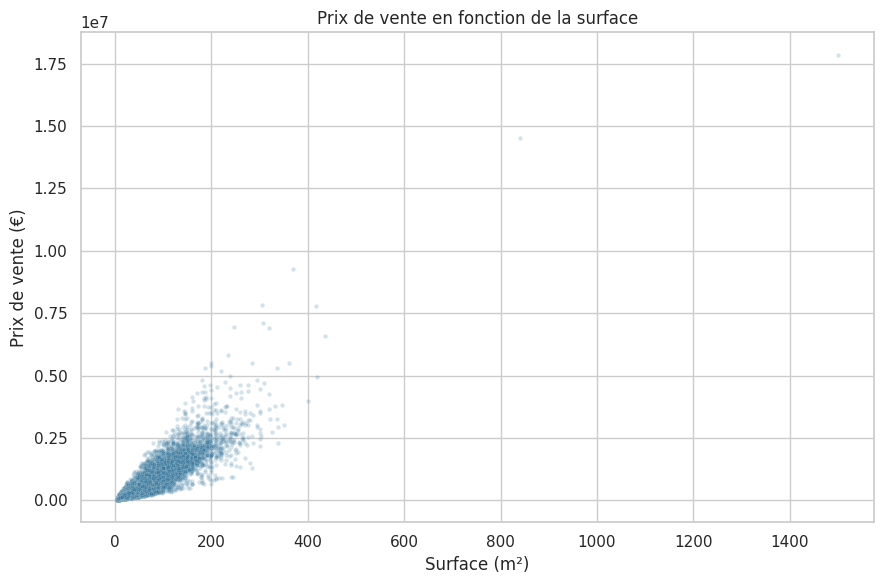

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_flats, x="surface_reelle_bati", y="valeur_fonciere", alpha=0.2, s=10, color="#2a6f97")
plt.title("Prix de vente en fonction de la surface")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix de vente (€)")
plt.tight_layout()
plt.show()

### Corrélations avec le prix

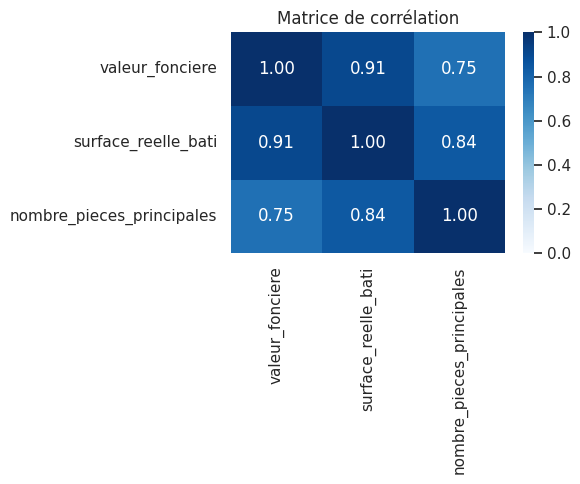

In [7]:
cols = ["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales"]
correlations = df_flats[cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

**Lecture :** la surface est très fortement corrélée au prix (environ 0,91), suivie du nombre de pièces (environ 0,75). Ces deux variables sont elles-mêmes liées : un grand appartement a généralement plus de pièces.

## 3. Modélisation : régression linéaire

L'arrondissement est une variable **catégorielle** (le 20e n'est pas « plus grand » que le 1er). On la transforme donc en une colonne par arrondissement (encodage *one-hot*).

In [8]:
X = df_flats[["surface_reelle_bati", "nombre_pieces_principales", "arrondissement"]]
y = df_flats["valeur_fonciere"]

X_encoded = pd.get_dummies(X, columns=["arrondissement"], prefix="arr", dtype=int, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)

print(f"Jeu d'entraînement : {X_train.shape[0]:,} appartements".replace(",", " "))
print(f"Jeu de test        : {X_test.shape[0]:,} appartements".replace(",", " "))

Jeu d'entraînement : 39 136 appartements
Jeu de test        : 9 785 appartements


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 4. Évaluation

In [10]:
r2_train = model.score(X_train, y_train)
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² entraînement : {r2_train:.3f}")
print(f"R² test         : {r2_test:.3f}")
print(f"Erreur moyenne absolue (MAE) : {mae:,.0f} €".replace(",", " "))

R² entraînement : 0.848
R² test         : 0.850
Erreur moyenne absolue (MAE) : 92 322 €


**Lecture :**
- Le **R²** d'environ 0,85 signifie que le modèle explique environ 85 % des écarts de prix entre appartements.
- Les scores sur les jeux d'entraînement et de test sont proches : le modèle **généralise bien**, sans surapprentissage.
- La **MAE** d'environ 92 000 € correspond à l'erreur moyenne du modèle. Pour un prix médian de 370 000 €, c'est une estimation utile comme première approche, mais pas assez précise pour fixer un prix de vente.

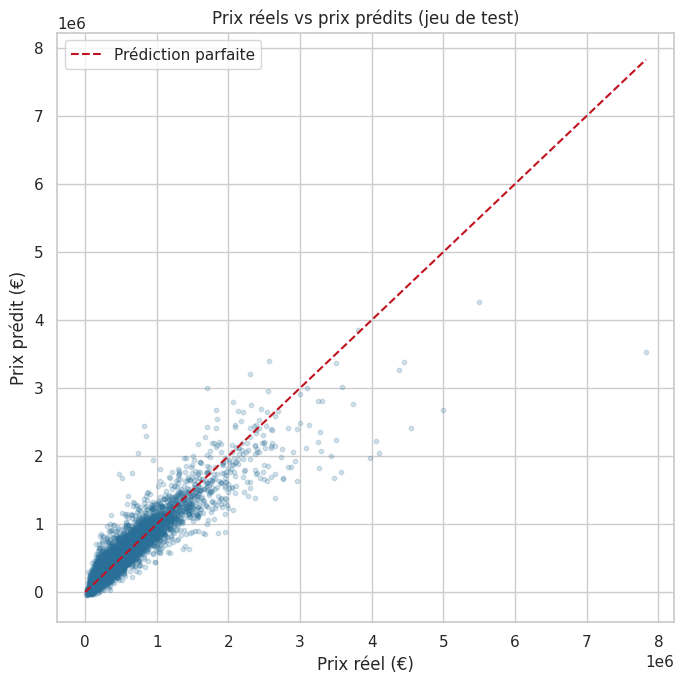

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.2, s=10, color="#2a6f97")
limite = max(y_test.max(), y_pred.max())
plt.plot([0, limite], [0, limite], color="#c1121f", linestyle="--", label="Prédiction parfaite")
plt.title("Prix réels vs prix prédits (jeu de test)")
plt.xlabel("Prix réel (€)")
plt.ylabel("Prix prédit (€)")
plt.legend()
plt.tight_layout()
plt.show()

### Ce que le modèle a appris

Prix d'un m² supplémentaire      : 11 500 €
Effet d'une pièce supplémentaire : -8 672 €


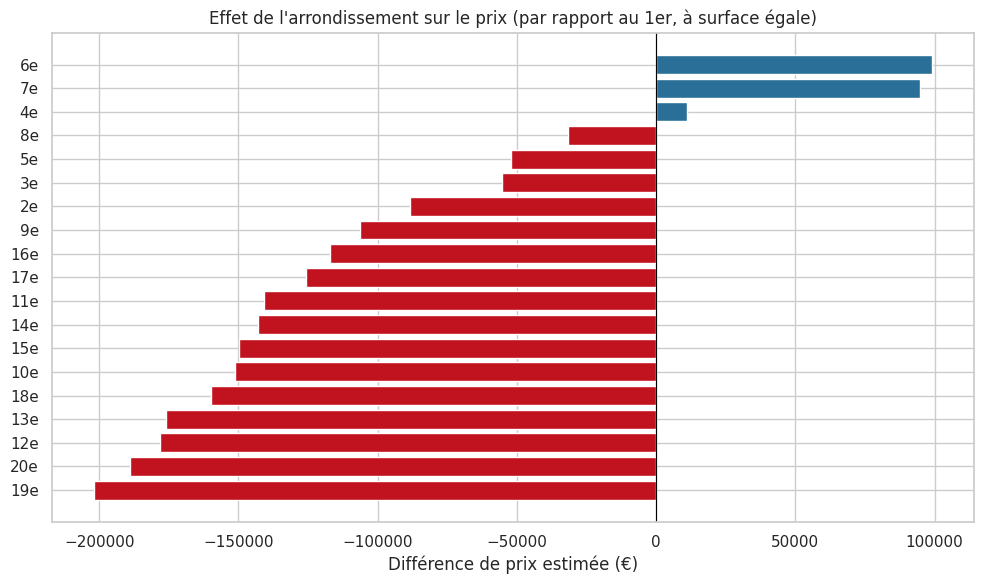

In [12]:
coefficients = pd.Series(model.coef_, index=X_encoded.columns)

print(f"Prix d'un m² supplémentaire      : {coefficients['surface_reelle_bati']:,.0f} €".replace(",", " "))
print(f"Effet d'une pièce supplémentaire : {coefficients['nombre_pieces_principales']:,.0f} €".replace(",", " "))

effet_arr = coefficients.filter(like="arr_").sort_values()
effet_arr.index = effet_arr.index.str.replace("arr_", "") + "e"

plt.figure(figsize=(10, 6))
couleurs = ["#c1121f" if v < 0 else "#2a6f97" for v in effet_arr.values]
plt.barh(effet_arr.index, effet_arr.values, color=couleurs)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Effet de l'arrondissement sur le prix (par rapport au 1er, à surface égale)")
plt.xlabel("Différence de prix estimée (€)")
plt.tight_layout()
plt.show()

**Lecture :** à surface et nombre de pièces égaux, le modèle estime combien un appartement vaut de plus ou de moins qu'un appartement situé dans le 1er arrondissement (arrondissement de référence).

**Point d'attention :** le coefficient du nombre de pièces est légèrement négatif (environ -8 700 €). Cela ne veut pas dire qu'une pièce en plus fait baisser le prix : comme la surface et le nombre de pièces sont très liés, le modèle attribue presque toute la valeur à la surface. À surface égale, un appartement découpé en plus de pièces a simplement des pièces plus petites, ce qui ne le valorise pas davantage.

### Exemple de prédiction

In [13]:
def estimer_prix(surface, pieces, arrondissement):
    exemple = pd.DataFrame(0, index=[0], columns=X_encoded.columns)
    exemple["surface_reelle_bati"] = surface
    exemple["nombre_pieces_principales"] = pieces
    colonne = f"arr_{arrondissement}"
    if colonne in exemple.columns:
        exemple[colonne] = 1
    return model.predict(exemple)[0]

for surface, pieces, arr in [(30, 1, 18), (50, 2, 11), (80, 3, 7)]:
    prix = estimer_prix(surface, pieces, arr)
    prix_txt = f"{prix:,.0f}".replace(",", " ")
    print(f"{surface} m², {pieces} pièce(s), {arr}e arrondissement : environ {prix_txt} €")

30 m², 1 pièce(s), 18e arrondissement : environ 262 178 €
50 m², 2 pièce(s), 11e arrondissement : environ 502 553 €
80 m², 3 pièce(s), 7e arrondissement : environ 1 074 455 €


## 5. Limites et pistes d'amélioration

**Limites :**
- Le modèle ne connaît que trois informations. Il ignore l'étage, l'état du bien, la présence d'un balcon, l'exposition ou la proximité du métro.
- La régression linéaire suppose que le prix augmente de façon régulière avec la surface, ce qui est moins vrai pour les biens très grands ou atypiques.
- Les données datent de 2018-2019 : les prix parisiens ont évolué depuis.
- Une seule séparation entraînement/test donne une seule estimation de la performance.

**Pistes d'amélioration :**
- Utiliser la **validation croisée** pour une évaluation plus robuste.
- Tester des modèles non linéaires (**Random Forest**, **Gradient Boosting**).
- Ajouter des variables : quartier (IRIS), coordonnées GPS, date de vente.
- Exploiter le texte des annonces (état, atouts, proximité) avec des techniques de **NLP** (TF-IDF).